In [16]:
# pip-installs
!pip install -q torchmetrics scikit-learn


In [17]:
import os
import zipfile
from google.colab import drive
from tqdm.auto import tqdm

unzipped_images_dir = '/content/my_images/GCD'
zip_path = '/content/drive/MyDrive/Colab Notebooks/GCD.zip'
expected_image_count = 19000

def count_files_with_progress(directory, description):
    file_count = 0
    for root, dirs, files in tqdm(os.walk(directory), desc=description, unit="dir"):
        file_count += len(files)
    return file_count

def extract_zip_with_progress(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        for member in tqdm(members, desc="Unzipping files", unit="file"):
            zip_ref.extract(member, extract_to)

if os.path.exists(unzipped_images_dir) and os.listdir(unzipped_images_dir):
    current_image_count = count_files_with_progress(unzipped_images_dir, "Counting existing images")
    if current_image_count == expected_image_count:
        print(f"✅ Images already extracted to {unzipped_images_dir}. Skipping extraction. ({current_image_count} files found)")
    else:
        print(f"⚠️ Images directory {unzipped_images_dir} exists but contains {current_image_count} files instead of the expected {expected_image_count}.")
        user_response = input("Do you want to re-extract the images? (yes/no): ").strip().lower()
        if user_response == 'yes':
            print("Proceeding with re-extraction...")
            drive.mount('/content/drive')
            if os.path.exists(zip_path):
                print("✅ Zip file found! Starting re-extraction...")
                os.makedirs('/content/my_images', exist_ok=True)
                extract_zip_with_progress(zip_path, '/content/my_images')
                final_image_count = count_files_with_progress(unzipped_images_dir, "Counting re-extracted images")
                if final_image_count == expected_image_count:
                    print(f"🎉 Re-extraction complete and verified! ({final_image_count} files found)")
                else:
                    print(f"❌ Re-extraction complete, but found {final_image_count} files instead of {expected_image_count}.")
            else:
                print(f"❌ Error: Zip file not found at {zip_path}")
        else:
            print(f"Skipping re-extraction. Using existing images ({current_image_count} files).")
else:
    print(f"Images not found in {unzipped_images_dir}. Proceeding with extraction...")
    drive.mount('/content/drive')
    if os.path.exists(zip_path):
        print("✅ Zip file found! Starting extraction...")
        os.makedirs('/content/my_images', exist_ok=True)
        extract_zip_with_progress(zip_path, '/content/my_images')
        final_image_count = count_files_with_progress(unzipped_images_dir, "Counting extracted images")
        if final_image_count == expected_image_count:
            print(f"🎉 Extraction complete and verified! ({final_image_count} files found)")
        else:
            print(f"❌ Extraction complete, but found {final_image_count} files instead of {expected_image_count}.")
    else:
        print(f"❌ Error: Zip file not found at {zip_path}")
        print("Double check if there is a typo in 'Colab Notebooks' or the filename.")

Counting existing images: 0dir [00:00, ?dir/s]

✅ Images already extracted to /content/my_images/GCD. Skipping extraction. (19000 files found)


# CloudDenseNet — DenseNet121 Transfer Learning on GCD (Balanced 60/20/20)

Variant of notebook 15 with a balanced, pooled dataset split.

**Dataset strategy:**
- Pool `GCD/train/` and `GCD/test/` into one corpus (18,200 images across 7 classes)
- Balance each class to exactly 3,000 images:
  - Oversample (with replacement) classes below 3,000
  - Downsample (without replacement) classes above 3,000
- Stratified 60/20/20 split → **12,600 train / 4,200 val / 4,200 test**

**Target:** 93.43% test accuracy (paper benchmark on GCD).

**Training schedule:**

| Phase | Layers unfrozen | Head LR | Backbone LR | Epochs |
|-------|----------------|---------|-------------|--------|
| 1 | TopBlock only | 1e-4 | — | 10 |
| 2 | TopBlock only | 1e-5 | — | 10 |
| 3 | TopBlock + DenseBlock3 onwards | 1e-5 | 5e-5 | 20 |
| 4 | TopBlock + DenseBlock3 onwards | 1e-5 | 1e-5 | 20 |
| 5 | All layers | 1e-6 | 1e-6 | 20 |

In [18]:

# index-images — walks the extracted GCD directory to build the image list
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

GCD_ROOT      = Path(unzipped_images_dir)   # defined in drive-mount cell above
MAX_PER_CLASS = 3000

def index_gcd_balanced(root, max_per_class=3000, random_state=42):
    rng = np.random.default_rng(random_state)

    by_class = defaultdict(list)
    for split in ["train", "test"]:
        split_dir = root / split
        if not split_dir.is_dir():
            raise FileNotFoundError(f"Expected directory: {split_dir}")
        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                by_class[class_dir.name].extend(
                    str(p) for p in sorted(class_dir.glob("*.jpg"))
                )

    paths, labels = [], []
    for label in sorted(by_class):
        imgs = by_class[label]
        chosen = rng.choice(imgs, size=max_per_class,
                            replace=(len(imgs) < max_per_class))
        paths.extend(chosen.tolist())
        labels.extend([label] * max_per_class)

    return np.array(paths), np.array(labels)


all_paths, all_labels = index_gcd_balanced(GCD_ROOT, MAX_PER_CLASS)

print(f"Total images (balanced): {len(all_paths):,}")
for cls, cnt in sorted(Counter(all_labels).items()):
    print(f"  {cls:25s}  {cnt:,}")


Total images (balanced): 21,000
  1_cumulus                  3,000
  2_altocumulus              3,000
  3_cirrus                   3,000
  4_clearsky                 3,000
  5_stratocumulus            3,000
  6_cumulonimbus             3,000
  7_mixed                    3,000


In [19]:
import torch

if torch.cuda.is_available():
    device = "cuda"
    # Optimizes convolution operations for fixed input sizes
    torch.backends.cudnn.benchmark = True

    # Enable TF32 for Ampere (A100) GPUs for faster matrix multiplications
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")

device: cuda


In [20]:
import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (224, 224)
MAX_FRAC = 0.14


class WrapTranslation:
    """Picklable cyclic-shift augmentation (torch.roll). Safe with num_workers > 0."""
    def __init__(self, max_frac: float = 0.14):
        self.max_frac = max_frac

    def __call__(self, x):
        h_shift = int(torch.randint(
            -int(self.max_frac * x.shape[-2]),
             int(self.max_frac * x.shape[-2]) + 1, (1,)).item())
        w_shift = int(torch.randint(
            -int(self.max_frac * x.shape[-1]),
             int(self.max_frac * x.shape[-1]) + 1, (1,)).item())
        return torch.roll(x, shifts=(h_shift, w_shift), dims=(-2, -1))


border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

wrap_translation = WrapTranslation(MAX_FRAC)

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])


In [21]:
import torchvision
import torch.nn as nn

weights = torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
model = torchvision.models.densenet121(weights=weights).to(device)
print("DenseNet121 loaded")

DenseNet121 loaded


In [22]:
from sklearn.preprocessing import LabelEncoder

le          = LabelEncoder()
all_encoded = le.fit_transform(all_labels)
class_names = le.classes_
n_classes   = len(class_names)
print(f"Classes ({n_classes}): {class_names}")

Classes (7): ['1_cumulus' '2_altocumulus' '3_cirrus' '4_clearsky' '5_stratocumulus'
 '6_cumulonimbus' '7_mixed']


In [23]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image


class GCDDataset(Dataset):
    def __init__(self, paths, encoded_labels, transform=None):
        self.paths          = list(paths)
        self.encoded_labels = list(encoded_labels)
        self.transform      = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


# 60 / 20 / 20 stratified split
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, valtest_idx = next(sss1.split(all_paths, all_encoded))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_rel, test_rel = next(sss2.split(all_paths[valtest_idx], all_encoded[valtest_idx]))
val_idx  = valtest_idx[val_rel]
test_idx = valtest_idx[test_rel]

train_set = GCDDataset(all_paths[train_idx],  all_encoded[train_idx],  transform=train_transforms)
valid_set = GCDDataset(all_paths[val_idx],    all_encoded[val_idx],    transform=eval_transforms)
test_set  = GCDDataset(all_paths[test_idx],   all_encoded[test_idx],   transform=eval_transforms)

print(f"train: {len(train_set):,}  val: {len(valid_set):,}  test: {len(test_set):,}")

train: 12,600  val: 4,200  test: 4,200


In [24]:
import os
from torch.utils.data import DataLoader, WeightedRandomSampler

train_labels_list = train_set.encoded_labels
class_counts   = np.bincount(train_labels_list)
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor(
    [class_weights[l] for l in train_labels_list], dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Use all available CPU cores to keep the A100 fed
optimal_workers = os.cpu_count() or 2
print(f"Optimizing DataLoaders to use {optimal_workers} workers.")

# Increased batch size to 128 for A100 VRAM, added pin_memory and persistent_workers
train_loader = DataLoader(train_set, batch_size=128, sampler=sampler,  num_workers=optimal_workers, pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_set, batch_size=128, num_workers=optimal_workers, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_set,  batch_size=128, num_workers=optimal_workers, pin_memory=True, persistent_workers=True)


Optimizing DataLoaders to use 12 workers.


In [25]:
class TopBlock(nn.Module):
    """
    Custom classification head from CloudDenseNet (Li et al., Sensors 2023).

    Replaces DenseNet121's single linear classifier with a 2-layer MLP:
      BN → Dropout → Linear(1024, hidden) → ReLU → BN → Dropout → Linear(hidden, n_classes)

    Weights are initialised with LeCun uniform distribution, as specified in the paper.
    """
    def __init__(self, in_features: int, n_classes: int,
                 hidden_dim: int = 512, dropout: float = 0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )
        self._lecun_init()

    def _lecun_init(self):
        for m in self.block:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.block(x)


for param in model.parameters():
    param.requires_grad = False

model.classifier = TopBlock(
    in_features=1024,
    n_classes=n_classes,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Classes ({n_classes}): {class_names}")
print(f"Trainable params: {trainable:,} / {total:,}")

Classes (7): ['1_cumulus' '2_altocumulus' '3_cirrus' '4_clearsky' '5_stratocumulus'
 '6_cumulonimbus' '7_mixed']
Trainable params: 531,463 / 7,485,319


In [26]:
import torchmetrics
import torch

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            # Use non_blocking to overlap transfers
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            # Use autocast for faster inference evaluation
            with torch.amp.autocast('cuda'):
                metric.update(model(X_batch), y_batch)
    return metric.compute()

In [27]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017).

    Down-weights easy (high-confidence) examples so the model focuses on
    hard, misclassified ones.  gamma=0 reduces to standard cross-entropy.
    """
    def __init__(self, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce)
        loss = ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


focal_loss = FocalLoss(gamma=2.0).to(device)
print("FocalLoss ready (gamma=2.0)")

FocalLoss ready (gamma=2.0)


In [28]:
import time
import torch
from tqdm.auto import tqdm

def train_phase(model, optimizer, loss_fn, metric,
                train_loader, valid_loader,
                n_epochs, patience, checkpoint_path, phase_label=''):
    """
    Run one phase of the gradual-unfreeze schedule.

    Keeps frozen BatchNorm layers in eval mode so their running statistics
    are not corrupted; only BN layers with requires_grad=True are trained.
    Best weights are saved to checkpoint_path and restored before returning.
    """
    history    = {'train_losses': [], 'train_metrics': [], 'valid_metrics': []}
    best_val   = 0.0
    no_improve = 0

    # Initialize GradScaler for Mixed Precision Training (Updated API)
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(n_epochs):
        epoch_start_time = time.time()
        model.eval()
        model.classifier.train()
        for module in model.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                if any(p.requires_grad for p in module.parameters()):
                    module.train()

        total_loss = 0.0
        metric.reset()

        pbar = tqdm(train_loader, desc=f"[{phase_label}] Epoch {epoch+1}/{n_epochs}", leave=False)
        for X_batch, y_batch in pbar:
            # non_blocking=True overlaps data transfer with GPU computation
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad()

            # Enable mixed precision for forward pass (Updated API)
            with torch.amp.autocast('cuda'):
                y_pred = model(X_batch)
                loss   = loss_fn(y_pred, y_batch)

            # Backward pass and optimize using the scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            metric.update(y_pred, y_batch)
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        epoch_mins = (time.time() - epoch_start_time) / 60.0

        history['train_losses'].append(train_loss)
        history['train_metrics'].append(train_acc)
        history['valid_metrics'].append(val_acc)

        star = ' *' if val_acc > best_val else ''
        print(f'[{phase_label}] Epoch {epoch+1}/{n_epochs} | '
              f'loss: {train_loss:.4f} | '
              f'train: {train_acc:.4f} | '
              f'val: {val_acc:.4f}{star} | '
              f'time: {epoch_mins:.2f} min')

        if val_acc > best_val:
            best_val   = val_acc
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch+1} '
                      f'(best val: {best_val:.4f})')
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history, best_val

In [29]:
accuracy    = torchmetrics.Accuracy(task='multiclass', num_classes=n_classes).to(device)
CKPT        = 'best_cloudensenet_15_1.pt'
all_history = []

# ── Phase 1 — TopBlock only, LR = 1e-4, 10 epochs ───────────────────────────
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4, fused=True)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 1 (head, 1e-4)')
all_history.append(h)

# ── Phase 2 — TopBlock only, LR = 1e-5, 10 epochs ───────────────────────────
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-5, weight_decay=1e-4, fused=True)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 2 (head, 1e-5)')
all_history.append(h)

# ── Phase 3 — unfreeze DenseBlock3 onwards, LR = 5e-5 backbone, 20 epochs ──
unfreeze_from = ['features.denseblock3', 'features.transition3',
                 'features.denseblock4', 'features.norm5']
for name, param in model.named_parameters():
    if any(name.startswith(p) for p in unfreeze_from):
        param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith('classifier')]
head_params     = list(model.classifier.parameters())

opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 5e-5},
], weight_decay=1e-4, fused=True)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT,
                   phase_label='Phase 3 (denseblock3+, 5e-5)')
all_history.append(h)

# ── Phase 4 — same unfrozen scope, LR = 1e-5, 20 epochs ────────────────────
opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 1e-5},
], weight_decay=1e-4, fused=True)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT,
                   phase_label='Phase 4 (denseblock3+, 1e-5)')
all_history.append(h)

# ── Phase 5 — all layers, LR = 1e-6, 20 epochs ──────────────────────────────
for param in model.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-4, fused=True)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT,
                   phase_label='Phase 5 (all, 1e-6)')
all_history.append(h)

test_acc = evaluate_tm(model, test_loader, accuracy)
print(f'\nFinal test accuracy: {test_acc:.4f}  (target: 0.9343)')

[Phase 1 (head, 1e-4)] Epoch 1/10:   0%|          | 0/99 [00:00<?, ?it/s]

[Phase 1 (head, 1e-4)] Epoch 1/10 | loss: 0.8937 | train: 0.5127 | val: 0.7417 * | time: 0.44 min


[Phase 1 (head, 1e-4)] Epoch 2/10:   0%|          | 0/99 [00:00<?, ?it/s]

[Phase 1 (head, 1e-4)] Epoch 2/10 | loss: 0.5377 | train: 0.6686 | val: 0.7795 * | time: 0.38 min


[Phase 1 (head, 1e-4)] Epoch 3/10:   0%|          | 0/99 [00:00<?, ?it/s]

...

[Phase 5 (all, 1e-6)] Epoch 18/20 | loss: 0.1262 | train: 0.8824 | val: 0.9086 * | time: 0.43 min


[Phase 5 (all, 1e-6)] Epoch 19/20:   0%|          | 0/99 [00:00<?, ?it/s]

[Phase 5 (all, 1e-6)] Epoch 19/20 | loss: 0.1243 | train: 0.8860 | val: 0.9086 | time: 0.43 min


[Phase 5 (all, 1e-6)] Epoch 20/20:   0%|          | 0/99 [00:00<?, ?it/s]

[Phase 5 (all, 1e-6)] Epoch 20/20 | loss: 0.1263 | train: 0.8863 | val: 0.9086 | time: 0.42 min

Final test accuracy: 0.9152  (target: 0.9343)


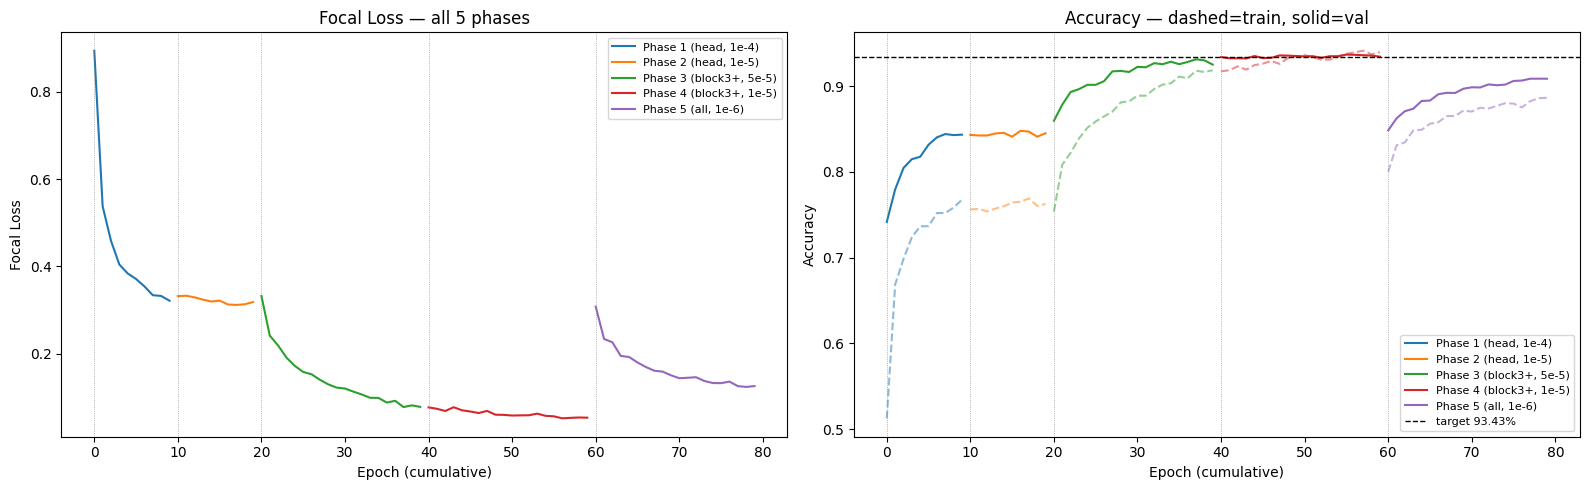

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [
    'Phase 1 (head, 1e-4)',
    'Phase 2 (head, 1e-5)',
    'Phase 3 (block3+, 5e-5)',
    'Phase 4 (block3+, 1e-5)',
    'Phase 5 (all, 1e-6)',
]

offset = 0
for h, label, color in zip(all_history, labels, colors):
    xs = list(range(offset, offset + len(h['train_losses'])))
    axes[0].plot(xs, h['train_losses'], color=color, label=label)
    axes[1].plot(xs, h['train_metrics'], color=color, linestyle='--', alpha=0.5)
    axes[1].plot(xs, h['valid_metrics'],  color=color, label=label)
    for ax in axes:
        ax.axvline(x=offset, color='grey', linewidth=0.5, linestyle=':')
    offset += len(h['train_losses'])

axes[0].set_title('Focal Loss — all 5 phases')
axes[0].set_xlabel('Epoch (cumulative)')
axes[0].set_ylabel('Focal Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Accuracy — dashed=train, solid=val')
axes[1].set_xlabel('Epoch (cumulative)')
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.9343, color='black', linewidth=1.0, linestyle='--', label='target 93.43%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
import shutil

drive_save_path = '/content/drive/MyDrive/Colab Notebooks/best_cloudensenet_15_1.pt'
shutil.copy(CKPT, drive_save_path)
print(f'Checkpoint saved to Drive: {drive_save_path}')


Checkpoint saved to Drive: /content/drive/MyDrive/Colab Notebooks/best_cloudensenet_15_1.pt


Generating predictions for the test set...


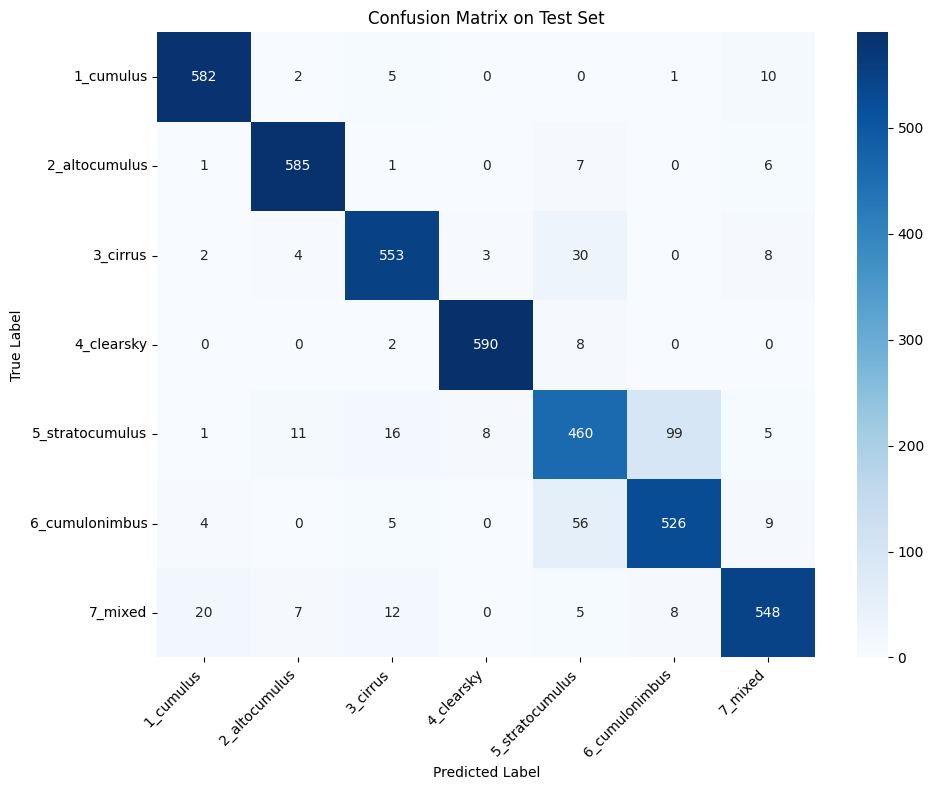

In [32]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Put model in evaluation mode
model.eval()
all_preds = []
all_targets = []

print("Generating predictions for the test set...")
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        # Use mixed precision for faster inference
        with torch.amp.autocast('cuda'):
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()